In [1]:
# Jaxlib
import jax
from jax import lax
from jax import random as jrnd
from jax import numpy as jnp
from jax import tree_util as jtu
jax.config.update('jax_enable_x64', True)

# Others
from matplotlib import pyplot as plt

# This
from numerics import *
from seismic import *

In [2]:
site = Site(0., 0., 760., 0.5, 2.9, 1.)
mfd1 = MFD(4., .8, 4., 8.)
mfd2 = MFD(4., 1., 4., 8.)
mfd3 = MFD(5., 1.2, 4., 5.)
fault1 = Fault(0., 20., 3.0, 0.1, 40., 80., 90., 2.5, 0., mfd1)
fault2 = Fault(0., 25., 0.5, 0.2, 80., 80., 30., 0.5, 1., mfd2)
fault3 = Fault(22., 12.1, 3.9, 1.2, 130., 40., 22., 3., 1., mfd3)
fault_tree = make_fault_tree(fault1)
scn = Scenario(site, fault_tree)

In [43]:
collist = ['T', 'Vlin', 'b', 'n', 'M1', 'c', 'c4', 'a1', 'a2', 'a3', 'a4', 'a5', 'a6', 'a7', 'a8', 'a10', 'a11', 'a12', 'a13', 'a14', 'a15', 'a16', 'a17', 'a43', 'a44', 'a45', 'a46', 'a25', 'a28', 'a29', 'a31', 'a36', 'a37', 'a38', 'a39', 'a40', 'a41', 'a42', 's1e', 's2e', 's3', 's4', 's1m', 's2m', 's5', 's6']
for i,col in enumerate(collist):
    print(i, col)

0 T
1 Vlin
2 b
3 n
4 M1
5 c
6 c4
7 a1
8 a2
9 a3
10 a4
11 a5
12 a6
13 a7
14 a8
15 a10
16 a11
17 a12
18 a13
19 a14
20 a15
21 a16
22 a17
23 a43
24 a44
25 a45
26 a46
27 a25
28 a28
29 a29
30 a31
31 a36
32 a37
33 a38
34 a39
35 a40
36 a41
37 a42
38 s1e
39 s2e
40 s3
41 s4
42 s1m
43 s2m
44 s5
45 s6


In [63]:
import jax
from jax import lax
from jax.tree_util import Partial
from jax import numpy as jnp

import polars as pl
from importlib.resources import files

from seismic.gm_utils import *

##### GROUND MOTION COEFFICIENTS #####
gmc = pl.read_csv(files("seismic") / "ASK14_coeffs.csv")
gmc[-2, 'T'] = -1.
gmc[-1, 'T'] = -2.

gmc = gmc.with_columns([pl.col("T").cast(pl.Float64)])
gmc = gmc.sort('T')
gmc_col = gmc.columns
gmcdf = gmc
gmc = gmc.cast(pl.Float64).to_jax().T

T_ASK, v_lin_all, b_all, N_all, M1_all, c_all, c4_all = gmc[:7]
empty = jnp.zeros_like(T_ASK)
a1thru8_all = gmc[7:15]
a10thru17_all = gmc[15:23]
a43thru46_all = gmc[23:27]
a25_all, a28_all, a29_all, a31_all = gmc[27:31]
a36thru42_all = gmc[31:38]

a_all = jnp.concatenate([empty[None], a1thru8_all, empty[None], a10thru17_all] + \
                         7 * [empty[None]] + [a25_all[None]] + \
                         2 * [empty[None]] + \
                             [a28_all[None], a29_all[None], empty[None], a31_all[None]] + \
                         4 * [empty[None]] + \
                             [a36thru42_all, a43thru46_all])

s1est_all, s2est_all, s3_all, s4_all, s1m_all, s2m_all, s5_all, s6_all = gmc[38:]
s_all = jnp.stack([empty, s1m_all, s2m_all, 
                         s3_all, s4_all, 
                         s5_all, s6_all])
s_est_all = jnp.stack([empty, s1est_all, s2est_all])

M2 = 5.0
A = 610 ** 4
B = 1360 ** 4 + A
vs_rock = 1180
a2_HW = 0.2
H1, H2, H3 = 0.25, 1.5, -0.75
phi_amp_sq = 0.16
# Omit 1000 because of Jax interp behavior (constant extrapolation for
#   values above 700 so we don't need to worry about 1000)
vs30_bins = jnp.array([150., 250., 400., 700.])

# Also defining v1 so we don't need to do it twice
v1_all = jnp.exp(-0.35 * jnp.log(T_ASK / 0.5) + jnp.log(1500))
v1_all = v1_all.at[T_ASK <= 0.5].set(1500)
v1_all = v1_all.at[T_ASK >= 3].set(800)

other_all = jnp.stack([M1_all, b_all, c_all, c4_all, v_lin_all, v1_all, N_all])

coeffs_all = jnp.concat([a_all, s_all, s_est_all, other_all])

sigs = coeffs_all[47:57].shape

In [64]:
def slice_coeffs(T):
    T_idx = jnp.searchsorted(T_ASK, T) - 1
    T_slice = lax.dynamic_slice_in_dim(T_ASK, T_idx, 2, axis = -1)
    coeffs = lax.dynamic_slice_in_dim(coeffs_all, T_idx, 2, axis = -1)
    a = coeffs[:47]
    c_sigma = coeffs[47:57]
    c_other = coeffs[57:]
    return (T_slice, a, c_other, c_sigma)

def f_dAmp(vs30, SA_rock,
           c_other):
    _, b, c, _, v_lin, _, N = c_other
    dAmp = (-b * SA_rock) / (SA_rock + c) + (b * SA_rock) / (SA_rock + c * (vs30 / v_lin) ** N)
    return jnp.where(vs30 >= v_lin, 0., dAmp)

def f1(Mw, R_rup, R, a,
       M1):
    f1_base = a[1] + a[17] * R_rup
    M_floor = jnp.clip(Mw, min = M2)
    dM1 = M_floor - M1
    dM_max = (8.5 - M_floor) ** 2
    dM2 = Mw - M2
    
    A_capped = a[4] + (a[5] - a[4]) * (Mw > M1)
    dM2_coeff = (Mw < M2) * (a[6] * dM2)

    return f1_base + A_capped * dM1 + a[8] * dM_max + dM2_coeff * dM2 + jnp.log(R) * (a[2] + a[3] * dM1)

def f7_8(Mw, SOF_flag,
         a):
    lnSA_SOF = a[12] * jnp.clip(Mw - 4, min = 0, max = 1)
    return jnp.where(SOF_flag == 1., lnSA_SOF, 0.)

def f5(vs30, SA_rock,
       a, c_other):
    _, b, c, _, v_lin, v1, N = c_other
    vs30_star = jnp.clip(vs30, max = v1)
    return a[10] * jnp.log(vs30_star / v_lin) - b * jnp.log(SA_rock + c) + b * jnp.log(SA_rock + c * (vs30_star / v_lin) ** N)

def f4(Mw, width, dip, R_jb, R_x, z_tor,
       a):
    T1 = jnp.clip(2 - (dip / 45), min = 4 / 3)

    T2 = 1 + a2_HW * (Mw - 6.5) + jnp.where(Mw < 6.5, (1 - a2_HW) * (Mw - 6.5) ** 2, 0.)
    
    r1 = width * jnp.cos(jnp.deg2rad(dip))
    r2 = 3 * r1
    Rxr1 = R_x / r1
    leq_r1 = H1 + H2 * Rxr1 + H3 * Rxr1 ** 2
    mask_r1 = R_x <= r1

    leq_r2 = 1 - (R_x - r1) / (r2 - r1)
    mask_r2 = (r1 < R_x) & (R_x <= r2)

    T3 = 0. + leq_r1 * mask_r1 + leq_r2 * mask_r2

    T4 = 1 - z_tor ** 2 / 100

    T5 = 1 - R_jb / 30

    return a[13] * T1 * T2 * T3 * T4 * T5

def f6(z_tor, 
       a):
    return a[15] * jnp.clip(z_tor / 20, max = 1)

def f10(vs30, z1p0,
        a):
    z1p0_ref = jnp.exp(-7.67 / 4.0 * jnp.log((vs30 ** 4 + A) / B)) / 1000
    z1p0_soil = jax.vmap(jnp.interp, in_axes = (None, None, 1))(vs30, vs30_bins, a[43:47])
    z1p0_soil = z1p0_soil * jnp.log((z1p0 + 0.1) / (z1p0_ref + 0.1))
    return z1p0_soil

def f_lnSA_SA_rock(Mw, width, dip, z_tor, SOF_flag,
                   vs30, z1p0,
                   R_jb, R_rup, R_x,
                   a, c_other
                   ):
    M1, b, _, c4, v_lin, v1, N = c_other
    c4_mag = jnp.clip(c4 - (c4 - 1) * (5 - Mw), min = 1, max = c4)
    R = (R_rup ** 2 + c4_mag ** 2) ** (1 / 2)
    vs_rock_capped = jnp.clip(vs_rock, max = v1)
    lnSA5_rock = (a[10] + b * N) * jnp.log(vs_rock_capped / v_lin)
    
    lnSA1 = f1(Mw, R_rup, R, a, M1)
    lnSA7_8 = f7_8(Mw, SOF_flag, a)
    lnSA4 = f4(Mw, width, dip, R_jb, R_x, z_tor, a)
    lnSA6 = f6(z_tor, a)
    lnSA10 = f10(vs30, z1p0, a)

    SA_rock = jnp.exp(lnSA1 + lnSA7_8 + lnSA5_rock + lnSA4 + lnSA6)

    lnSA5 = f5(vs30, SA_rock, a, c_other)

    lnSA = lnSA1 + lnSA7_8 + lnSA5 + lnSA4 + lnSA6 + lnSA10 

    return lnSA, SA_rock

def f_sigma(Mw, vs30, vs30inf_flag, SA_rock,
            c_sigma, c_other):
    s_est, s = c_sigma[-2:], c_sigma[:-2]
    dAmp_p1 = f_dAmp(vs30, SA_rock, c_other) + 1
    vs30_s = jnp.where(vs30inf_flag == 1., s_est, s[1:3])

    phi_A = jnp.clip(vs30_s[1] + ((vs30_s[2] - vs30_s[1]) / 2) * (Mw - 4.0), min = s[1], max = s[2])
    phi_B_sq = phi_A ** 2 - phi_amp_sq
    phi_sq = phi_B_sq * dAmp_p1 ** 2 + phi_amp_sq

    tau_B = jnp.clip(s[3] + ((s[4] - s[3]) / 2) * (Mw - 4.0), min = s[3], max = s[4])
    tau = tau_B * dAmp_p1

    return (phi_sq + tau ** 2) ** (1 / 2)

def f_ASK14(Mw:float, T:float, site:Site, fault:Fault, R:jax.Array):
    T_slice, a, c_other, c_sigma = slice_coeffs(T) 

    SOF_flag = fault.calc_SOF_flag()
    R_jb, R_rup, R_epi, R_hyp, R_x = R
    
    lnSA, SA_rock = f_lnSA_SA_rock(Mw, fault.width, fault.dip, fault.z_tor, SOF_flag,
                                   site.vs30, site.z1p0, R_jb, R_rup, R_x,
                                   a, c_other)
    std = f_sigma(Mw, site.vs30, site.vs30inf_flag, SA_rock,
                  c_sigma, c_other)
    lnSA = jnp.interp(T, T_slice, lnSA)
    std = jnp.interp(T, T_slice, std)
    return lnSA, std

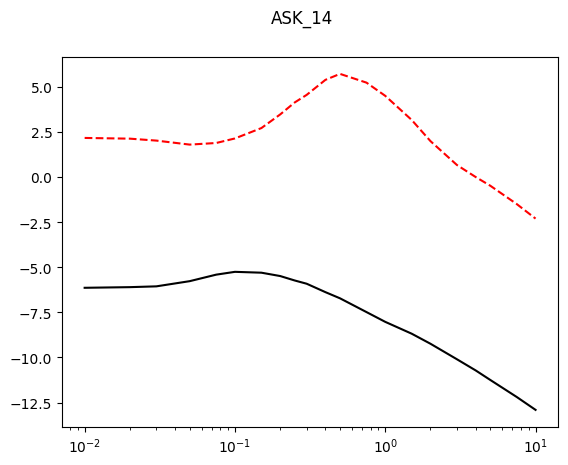

In [65]:
import requests

def test_model(Mw, fault:Fault, site:Site, name, model, apitest:bool = True):
    R = calc_R(site, fault)
    R_jb, R_rup, R_epi, R_hyp, R_x = R

    # API
    if apitest:
        url_base = 'https://earthquake.usgs.gov/ws/nshmp/gmm/spectra?'
        url_inputs = (name, Mw, R_jb, R_rup, R_x, fault.dip, fault.width, 
                    fault.z_tor, fault.z_hyp, fault.rake, 
                    site.vs30, site.z1p0, site.z2p5)
        url_addn = 'gmm=%s&Mw=%s&rJB=%s&rRup=%s&rX=%s&dip=%s&width=%s&z_tor=%s&z_hyp=%s&rake=%s&vs30=%s&z1p0=%s&z2p5=%s'%url_inputs
        json = requests.get(url_base + url_addn).json()
        api_T = json['response']['means']['data'][0]['data']['sa']['xs']
        api_PGA, api_PGV = [json['response']['means']['data'][0]['data'][key] for key in ['pga', 'pgv']]
        if api_PGV is None:
            api_PGV = jnp.nan
        api_SA = json['response']['means']['data'][0]['data']['sa']['ys']
        api_T, api_SA= [jnp.array(_) for _ in [api_T, api_SA]]
        #api_T = jnp.append(api_T, jnp.array([-1, -2]))
        #api_SA = jnp.append(api_SA, jnp.array([api_PGA, api_PGV]))
        api_lnSA = jnp.log(api_SA)
        my_lnSA, my_sigma = jax.vmap(model, in_axes = (None, 0, None, None, None))(Mw, api_T, site, fault, R)
        plt.plot(api_T, api_lnSA, c = 'k')
        plt.plot(api_T, my_lnSA, c = 'r', ls = '--')
    else:
        unif_T = [0.01, 0.02, 0.03, 0.05, 0.075, 0.1, 0.15, 0.2, 0.25, 0.3, 0.4, 0.5, 0.75, 1., 1.5, 2., 3., 4., 5., 7.5, 10.]
        unif_T = jnp.array(unif_T)
        my_lnSA, my_sigma = jax.vmap(model, in_axes = (None, 0, None, None, None))(Mw, unif_T, site, fault, R)
        plt.plot(unif_T, my_lnSA, c = 'r', ls = '--')
    plt.xscale('log')
    plt.suptitle(name)
    plt.show()

for m,n in [(f_ASK14, 'ASK_14')]:#zip([f_ASK14, f_Idriss14, f_BSSA14, f_CB14, f_CY14], 
           #    ['ASK_14', 'IDRISS_14', 'BSSA_14', 'CB_14', 'CY_14']):
    test_model(3.5, fault1, site, n, m, apitest = True)